In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [6]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [7]:
len(df)

18000

In [8]:
train_data = df.head(6000)
test_data = df.tail(12000)

In [12]:
train_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid3,165.0,166.0,169.0,165.0,167.0,166.0,166.0
1,rpi-8c,51.4,1568.9,16.4,17.7,17.3,17.1,17.6
2,odroid2,167.0,186.0,157.0,170.0,171.0,11.0,167.0
3,odroid2,164.0,347.0,154.0,170.0,170.0,170.0,168.0
4,odroid4,170.0,171.0,176.0,174.0,175.0,174.0,171.0
...,...,...,...,...,...,...,...,...
5995,odroid2,164.0,187.0,156.0,170.0,169.0,171.0,170.0
5996,rpi-8d,18.8,20.2,99.5,1691.4,21.2,20.2,19.5
5997,odroid4,170.0,171.0,174.0,171.0,173.0,175.0,174.0
5998,odroid2,164.0,184.0,156.0,172.0,172.0,170.0,170.0


In [11]:
test_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
6000,rpi-8d,1094.8,16.6,19.7,18.7,18.2,18.9,43.8
6001,odroid2,164.0,178.0,157.0,170.0,170.0,169.0,170.0
6002,rpi-4a,17.5,25.5,1157.3,422.2,16.2,19.3,18.5
6003,odroid1,165.0,167.0,169.0,166.0,167.0,167.0,168.0
6004,rpi-8b,226.1,449.4,31.7,233.7,233.9,449.2,16.4
...,...,...,...,...,...,...,...,...
17995,rpi-8a,430.1,15.9,233.3,433.7,15.3,233.1,234.1
17996,odroid2,180.0,175.0,156.0,169.0,170.0,170.0,9.0
17997,rpi-8c,14.8,15.8,139.7,19.6,50.7,88.5,31.2
17998,odroid4,171.0,174.0,174.0,174.0,173.0,175.0,174.0


In [10]:
predictor = TabularPredictor.load("../models/classification")

# Synthetic Adversarial Example - Naive

In [14]:
naive_results = pd.DataFrame(columns=['Interval', 'accuracy', 'balanced_accuracy', 'mcc'])
for i in range(1,26):
    print(i)
    noise = np.random.uniform(-i, i, size=(len(test_data), len(test_data.columns) - 1))
    naive_adversary = test_data.iloc[:, 1:] + noise
    naive_adversary = np.round(naive_adversary, decimals=1)
    naive_adversary['label'] = test_data.iloc[:, :1]

    y_pred = predictor.predict(naive_adversary)
    y_pred_proba = predictor.predict_proba(naive_adversary)
    results = predictor.evaluate(naive_adversary)

    new_results = {'Interval':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    naive_results.loc[len(naive_results)] = (new_results)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


In [16]:
naive_results

,Interval,accuracy,balanced_accuracy,mcc
0,1,0.887917,0.887759,0.874014
1,2,0.843250,0.842809,0.824082
2,3,0.806000,0.805288,0.783378
3,4,0.759583,0.758528,0.733328
4,5,0.718333,0.717157,0.688309
5,6,0.693417,0.692172,0.661890
6,7,0.667167,0.665945,0.632026
7,8,0.646417,0.645112,0.608919
8,9,0.634167,0.632922,0.594944
9,10,0.619667,0.618457,0.578308


## Which uniform intervals are able to fool the model?

<Axes: xlabel='Interval', ylabel='value'>

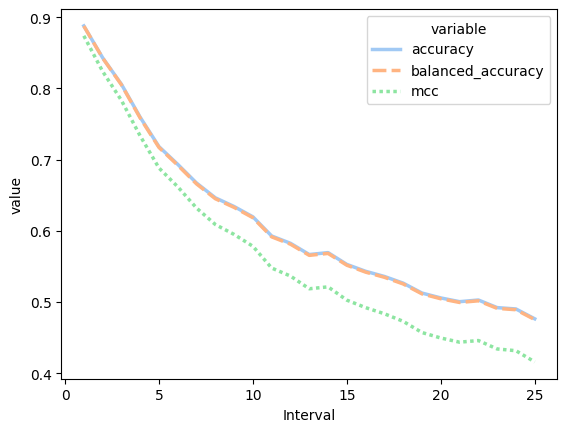

In [17]:
sns.lineplot(data=pd.melt(naive_results, ['Interval']), x='Interval', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

0.1 - 2.5 are able to fool the classification model with high accuracy

## Given an adversary uses an interval of 1, which IoT devices are most vulnerable to impersonation attacks?

In [18]:
naive_results = pd.DataFrame(columns=['Interval', 'accuracy', 'balanced_accuracy', 'mcc'])

noise = np.random.uniform(-1, 1, size=(len(test_data), len(test_data.columns) - 1))
naive_adversary = test_data.iloc[:, 1:] + noise
naive_adversary = np.round(naive_adversary, decimals=1)
naive_adversary['label'] = test_data.iloc[:, :1]

y_pred = predictor.predict(naive_adversary)
y_pred_proba = predictor.predict_proba(naive_adversary)
results = predictor.evaluate(naive_adversary)

new_results = {'Interval':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
naive_results.loc[len(naive_results)] = (new_results)

In [19]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(naive_adversary['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(naive_adversary['label']).count(device)

devices_fooled['accuracy'] *= 100

### All devices are vulerable to this attack

<Axes: xlabel='device', ylabel='accuracy'>

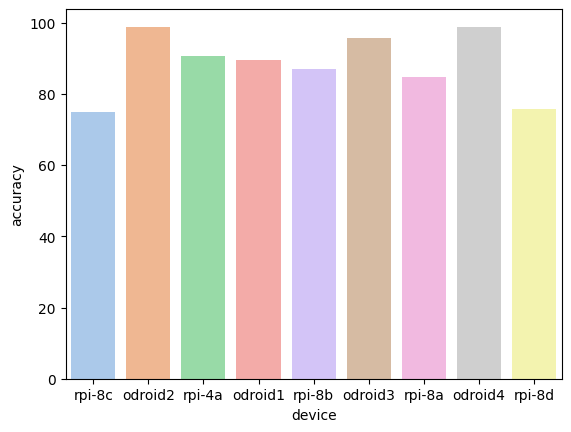

In [20]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Training anomaly detection model

Test/train data split:

We have 18k rows of IoT GPU Data
training data (5k) - genuine data
training data - held out (1k), used for testing on genuine unseen data.
testing data (12k) - impersonation data (we assume this data has been intercepted by an attacker, will be used for testing tolerance to noise on unseen data.)

Training split:
training_data.head(5000) - will be kept unmodified, genuine
training_data.head(5000) + noise - impersonation data used for training. using uniform intervals (1,25)

Test Split:
training_data.tail(1000) - genuine data that was held out from training.
testing data (1k) + noise - impersonation data used for testing. using uniform intervals (1,25)


## Training Data

### Genuine

In [89]:
genuine_training_data = train_data.head(5000).copy(deep=True)
genuine_training_data['label'] = 'genuine'

### Impersonator

In [90]:
impersonation_training_data = train_data.head(5000).drop(columns='label')

noise = np.round(np.random.uniform(low=-25, high=25, size=[5000,7]), 1)

impersonation_training_data = impersonation_training_data + noise

impersonation_training_data['label'] = 'impersonator'
impersonation_training_data

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,label
0,141.8,141.4,146.1,179.0,175.4,170.0,146.1,impersonator
1,29.3,1552.2,7.8,-2.0,17.1,24.9,13.9,impersonator
2,184.0,200.8,152.7,147.6,151.6,15.6,159.0,impersonator
3,176.8,322.1,170.3,176.6,145.3,170.9,167.0,impersonator
4,146.7,185.4,195.8,151.7,150.2,152.2,151.6,impersonator
...,...,...,...,...,...,...,...,...
4995,188.9,181.4,199.2,167.6,189.0,196.9,171.4,impersonator
4996,160.8,192.0,156.8,165.5,156.7,149.7,157.6,impersonator
4997,173.1,180.5,152.0,160.3,183.8,151.0,181.7,impersonator
4998,151.6,174.2,156.4,156.1,187.7,151.5,146.5,impersonator


<Axes: >

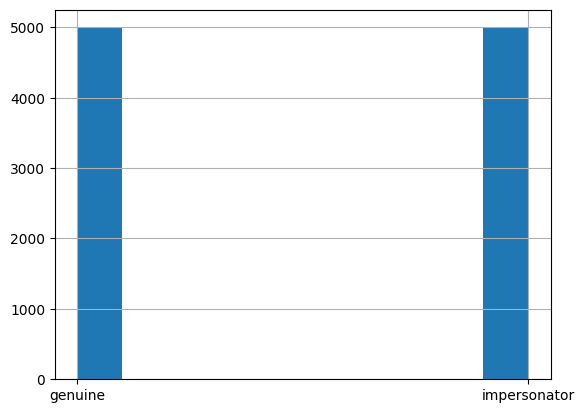

In [92]:
combined_training = pd.concat([impersonation_training_data, genuine_training_data])
combined_training = combined_training.sample(frac=1)
combined_training['label'].hist()

In [99]:
combined_training.to_csv('naive_training.csv')

## Testing Dataset

### Impersonator

In [77]:
impersonation_testing_data = test_data.drop(columns=['label'])[:1000]
noise = np.round(np.random.uniform(low=-25, high=25, size=[1000,7]), 1)

impersonation_testing_data = impersonation_testing_data + noise

impersonation_testing_data['label'] = 'impersonator'
impersonation_testing_data


,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,label
6000,1097.2,27.4,24.8,20.9,14.4,26.2,40.7,impersonator
6001,183.6,201.2,151.2,184.6,171.4,172.4,191.3,impersonator
6002,-3.9,4.9,1133.3,438.8,30.1,37.8,42.4,impersonator
6003,180.0,165.1,183.0,146.9,174.0,149.2,190.2,impersonator
6004,227.2,445.1,19.9,247.4,231.7,452.6,-7.7,impersonator
...,...,...,...,...,...,...,...,...
6995,20.4,2.6,753.4,23.2,11.1,1443.6,4.4,impersonator
6996,199.1,227.8,398.7,253.0,13.4,215.5,623.9,impersonator
6997,216.1,214.6,200.7,197.9,188.1,441.7,212.9,impersonator
6998,170.5,185.7,191.6,194.9,196.8,176.6,160.0,impersonator


### Genuine

In [81]:
testing_genuine = train_data.tail(1000).copy(deep=True)
testing_genuine['label'] = 'genuine'


<Axes: >

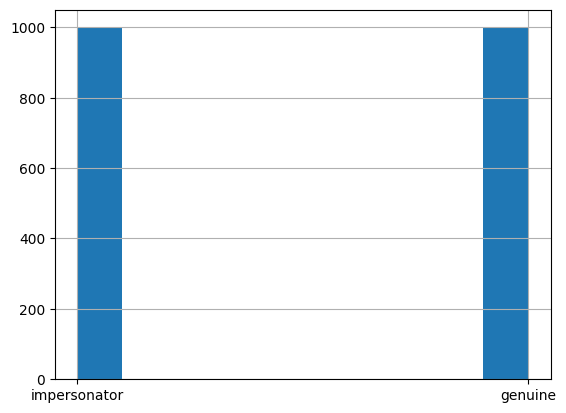

In [87]:
combined_testing = pd.concat([impersonation_testing_data, testing_genuine])
combined_testing['label'].hist()

In [98]:
# combined_testing.to_csv('naive_attack (testing).csv')

In [93]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

for training_data_size in range(1000, 10000, 1000):
    print(training_data_size)

    impersonation_detector = TabularPredictor(label='label').fit(combined_training[:training_data_size], num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    
    y_pred = impersonation_detector.predict(combined_testing)
    y_pred_proba = impersonation_detector.predict_proba(combined_testing)
    results = impersonation_detector.evaluate(combined_testing)

    new_results = {'data_amount':training_data_size, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250327_051831"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       52.29 GB / 63.72 GB (82.1%)
Disk Space Avail:   963.28 GB / 1906.98 GB (50.5%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250327_051831"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

1000


	0.915	 = Validation score   (accuracy)
	1.75s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.94	 = Validation score   (accuracy)
	2.0s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.935	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.93	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.87	 = Validation score   (accuracy)
	0.32s

2000


	0.97	 = Validation score   (accuracy)
	2.33s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.985	 = Validation score   (accuracy)
	2.02s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9675	 = Validation score   (accuracy)
	0.34s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9675	 = Validation score   (accuracy)
	0.32s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9475	 = Validation score   (accuracy)


...

	0.9814	 = Validation score   (accuracy)
	6.81s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9814	 = Validation score   (accuracy)
	3.55s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9786	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9786	 = Validation score   (accuracy)
	0.39s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9671	 = Validation score   (accurac

8000


	0.9762	 = Validation score   (accuracy)
	4.57s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9788	 = Validation score   (accuracy)
	2.3s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.975	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.975	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9563	 = Validation score   (accuracy)


9000
[1000]	valid_set's binary_error: 0.0211111


	0.9789	 = Validation score   (accuracy)
	4.79s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9811	 = Validation score   (accuracy)
	2.24s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9744	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9711	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9589	 = Validation score   (accurac

In [95]:
impersonation_detector.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,XGBoost,0.983333,accuracy,0.006006,1.198642,0.006006,1.198642,1,True,10
1,LightGBM,0.981111,accuracy,0.008698,2.237438,0.008698,2.237438,1,True,4
2,LightGBMXT,0.978889,accuracy,0.009446,4.790562,0.009446,4.790562,1,True,3
3,LightGBMLarge,0.975556,accuracy,0.016064,7.363607,0.016064,7.363607,1,True,12
4,RandomForestGini,0.974444,accuracy,0.044465,0.421257,0.044465,0.421257,1,True,5
5,RandomForestEntr,0.971111,accuracy,0.044534,0.423765,0.044534,0.423765,1,True,6
6,ExtraTreesEntr,0.965556,accuracy,0.043699,0.356515,0.043699,0.356515,1,True,8
7,ExtraTreesGini,0.958889,accuracy,0.043687,0.357316,0.043687,0.357316,1,True,7
8,NeuralNetTorch,0.928889,accuracy,0.000000,36.251678,0.000000,36.251678,1,True,11
9,KNeighborsUnif,0.684444,accuracy,0.024576,0.009933,0.024576,0.009933,1,True,1


## How much data is needed for decent model accuracy?

1000 noisy impersonator / 1000 genuine rows enough to train accurate model

<Axes: xlabel='data_amount', ylabel='value'>

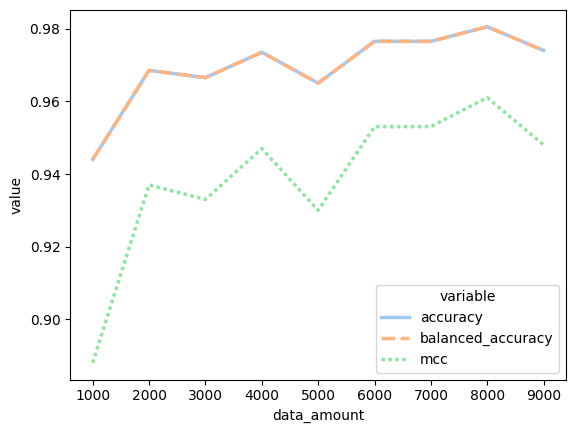

In [97]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)